# Digital Twin of CNC Turning Process
## Surface Quality Prediction — EDA · Preprocessing · XGBoost

**Dataset:** CNC Turning — Roughness, Forces and Tool Wear  
**Source:** [Kaggle — adorigueto](https://www.kaggle.com/datasets/adorigueto/cnc-turning-roughness-forces-and-tool-wear)  
**Origin:** Competence Center in Manufacturing (CCM) — ITA, Brazil

**Goal:** Predict surface roughness (Ra, Rku) in real time from machining parameters
and cutting force signals — enabling inline quality control without physical measurement stops.

---
### Structure
1. Imports & Setup  
2. Data Loading & Cleaning  
3. Exploratory Data Analysis  
4. Preprocessing & Feature Engineering  
5. XGBoost — Hyperparameter Search & Training  
6. Model Evaluation  
7. Summary  

In [ ]:
# 1. IMPORTS & SETUP

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

np.random.seed(42)

# Standard white background
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   'black',
    'axes.labelcolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'text.color':       'black',
    'grid.color':       '#cccccc',
    'grid.linestyle':   '--',
    'grid.alpha':       0.7,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'figure.dpi':       100,
})

PALETTE_TCOND = ['#1f77b4', '#ff7f0e', '#d62728']
C_RA   = '#2ca02c'
C_RKU  = '#1f77b4'


Libraries loaded OK


---
## 2. Data Loading & Cleaning

In [3]:
# ============================================================
# 2.1  LOAD CSV FILES

COLS_TO_DROP = [
    'Run_ID', 'Experiment', 'Replica', 'Tool_ID', 'Group', 'Subgroup',
    'Position', 'Condition', 'Machined_length', 'Init_diameter',
    'Final_diameter', 'CTime', 'R_measurement'
]

def clean(df, source_label):
    d = df.copy()
    d.drop(columns=[c for c in COLS_TO_DROP if c in d.columns], inplace=True)
    d['source'] = source_label
    if 'TCond' not in d.columns:
        d.insert(0, 'TCond', 0.0)
    return d

df1 = clean(pd.read_csv('Exp1.csv'), 'Exp1')
df2 = clean(pd.read_csv('Exp2.csv'), 'Exp2')

ROUGHNESS_COLS = ['Ra', 'Rz', 'Rsk', 'Rku', 'RSm', 'Rt']
FORCE_COLS     = ['Fx', 'Fy', 'Fz', 'F']
INPUT_COLS     = ['TCond', 'ap', 'vc', 'f']

print(f'Exp1 : {df1.shape}  (new tool only, 3^3 DoE)')
print(f'Exp2 : {df2.shape}  (tool wear: VBB = 0.0 / 0.1 / 0.3 mm)')

print('\nMissing values:', df2.isnull().sum().sum())
df2.describe().round(3)

Exp1 : (324, 15)  (new tool only, 3^3 DoE)
Exp2 : (288, 15)  (tool wear: VBB = 0.0 / 0.1 / 0.3 mm)

Missing values: 0


,TCond,ap,vc,f,Ra,Rz,Rsk,Rku,RSm,Rt,Fx,Fy,Fz,F
count,288.000,288.000,288.0,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000,288.000
mean,0.133,0.375,350.0,0.100,0.646,2.906,0.515,2.390,90.554,3.173,127.558,122.586,83.591,199.448
std,0.125,0.125,0.0,0.022,0.269,1.079,0.335,0.574,27.982,1.162,47.136,64.079,51.496,86.491
min,0.000,0.250,350.0,0.070,0.142,0.706,-0.285,1.443,31.400,0.840,51.500,44.640,24.170,73.725
25%,0.000,0.250,350.0,0.085,0.464,2.167,0.270,1.967,69.775,2.380,91.965,71.072,45.552,130.878
50%,0.100,0.375,350.0,0.100,0.613,2.762,0.512,2.316,89.900,3.021,117.700,102.850,75.875,184.038
75%,0.300,0.500,350.0,0.115,0.798,3.649,0.774,2.650,110.825,3.862,163.650,188.150,90.518,238.618
max,0.300,0.500,350.0,0.130,1.675,6.855,1.301,4.212,134.400,8.003,230.000,243.700,206.600,384.260


---
## 3. Exploratory Data Analysis

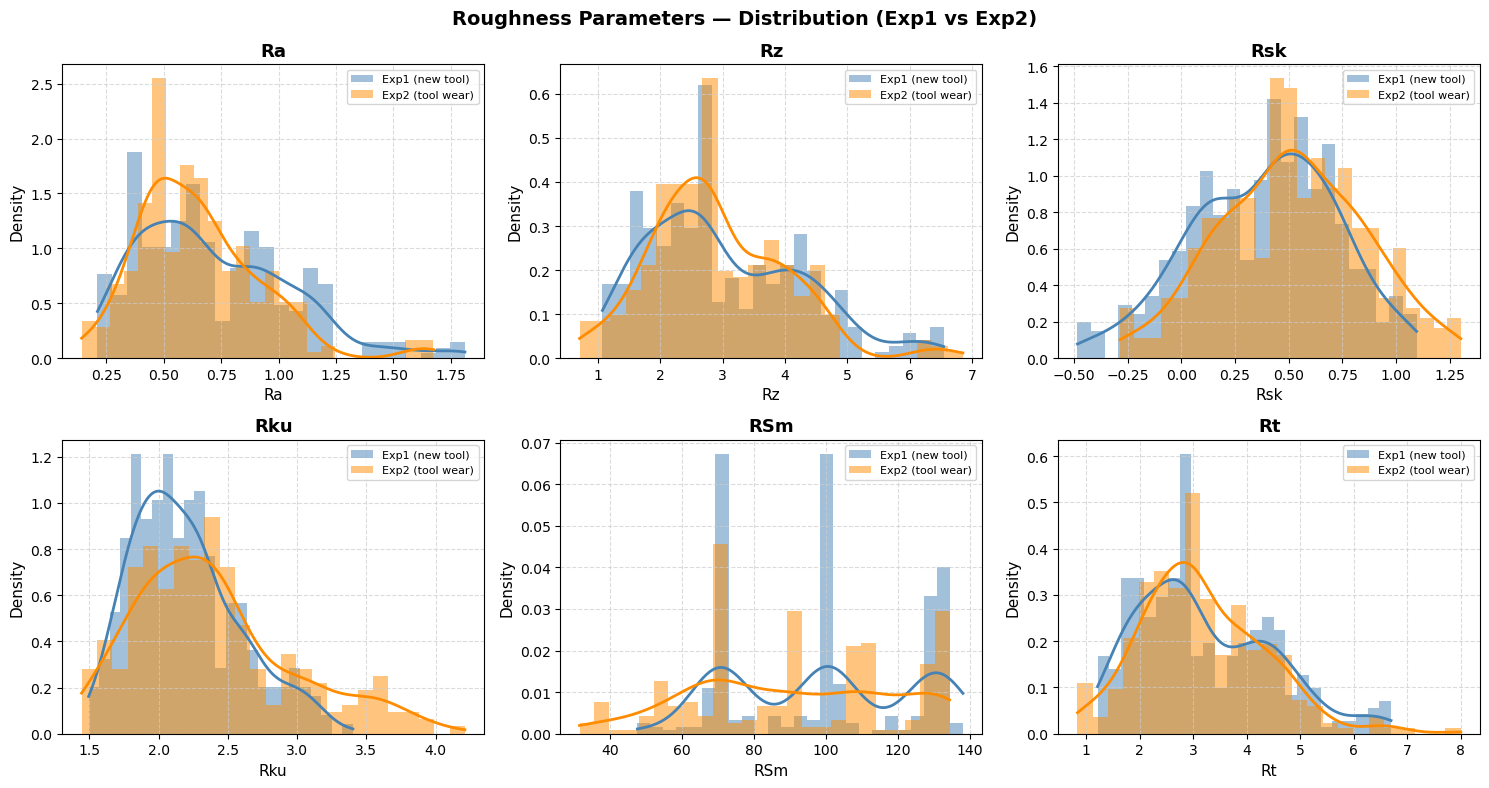

In [4]:
# ============================================================
# 3.1  ROUGHNESS DISTRIBUTIONS — Exp1 vs Exp2
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Roughness Parameters — Distribution (Exp1 vs Exp2)',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, ROUGHNESS_COLS):
    d1 = df1[col].dropna()
    d2 = df2[col].dropna()
    ax.hist(d1, bins=25, alpha=0.5, color='steelblue',
            label='Exp1 (new tool)', density=True)
    ax.hist(d2, bins=25, alpha=0.5, color='darkorange',
            label='Exp2 (tool wear)', density=True)
    for data, color in [(d1, 'steelblue'), (d2, 'darkorange')]:
        kde_x = np.linspace(data.min(), data.max(), 200)
        ax.plot(kde_x, stats.gaussian_kde(data)(kde_x), color=color, lw=2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('fig_01_roughness_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

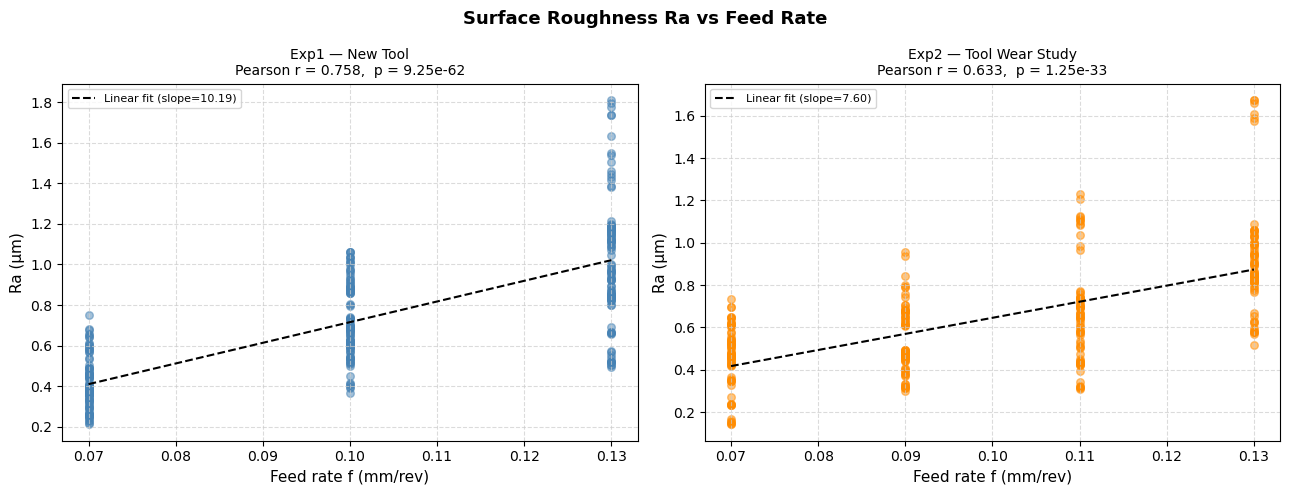

Insight: feed rate is the dominant driver of Ra — consistent with Ra ~ f^2/8r


In [5]:
# ============================================================
# 3.2  Ra vs FEED RATE
# Theoretical basis: Ra ~ f^2 / (8 * nose_radius)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Surface Roughness Ra vs Feed Rate', fontsize=13, fontweight='bold')

for ax, (df, label, color) in zip(axes, [
        (df1, 'Exp1 — New Tool',        'steelblue'),
        (df2, 'Exp2 — Tool Wear Study', 'darkorange')]):
    ax.scatter(df['f'], df['Ra'], alpha=0.5, s=30, color=color)
    m, b   = np.polyfit(df['f'], df['Ra'], 1)
    x_line = np.linspace(df['f'].min(), df['f'].max(), 100)
    ax.plot(x_line, m*x_line + b, color='black', lw=1.5,
            linestyle='--', label=f'Linear fit (slope={m:.2f})')
    r, p = stats.pearsonr(df['f'], df['Ra'])
    ax.set_title(f'{label}\nPearson r = {r:.3f},  p = {p:.2e}', fontsize=10)
    ax.set_xlabel('Feed rate f (mm/rev)')
    ax.set_ylabel('Ra (µm)')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('fig_02_Ra_vs_feed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Insight: feed rate is the dominant driver of Ra — consistent with Ra ~ f^2/8r')

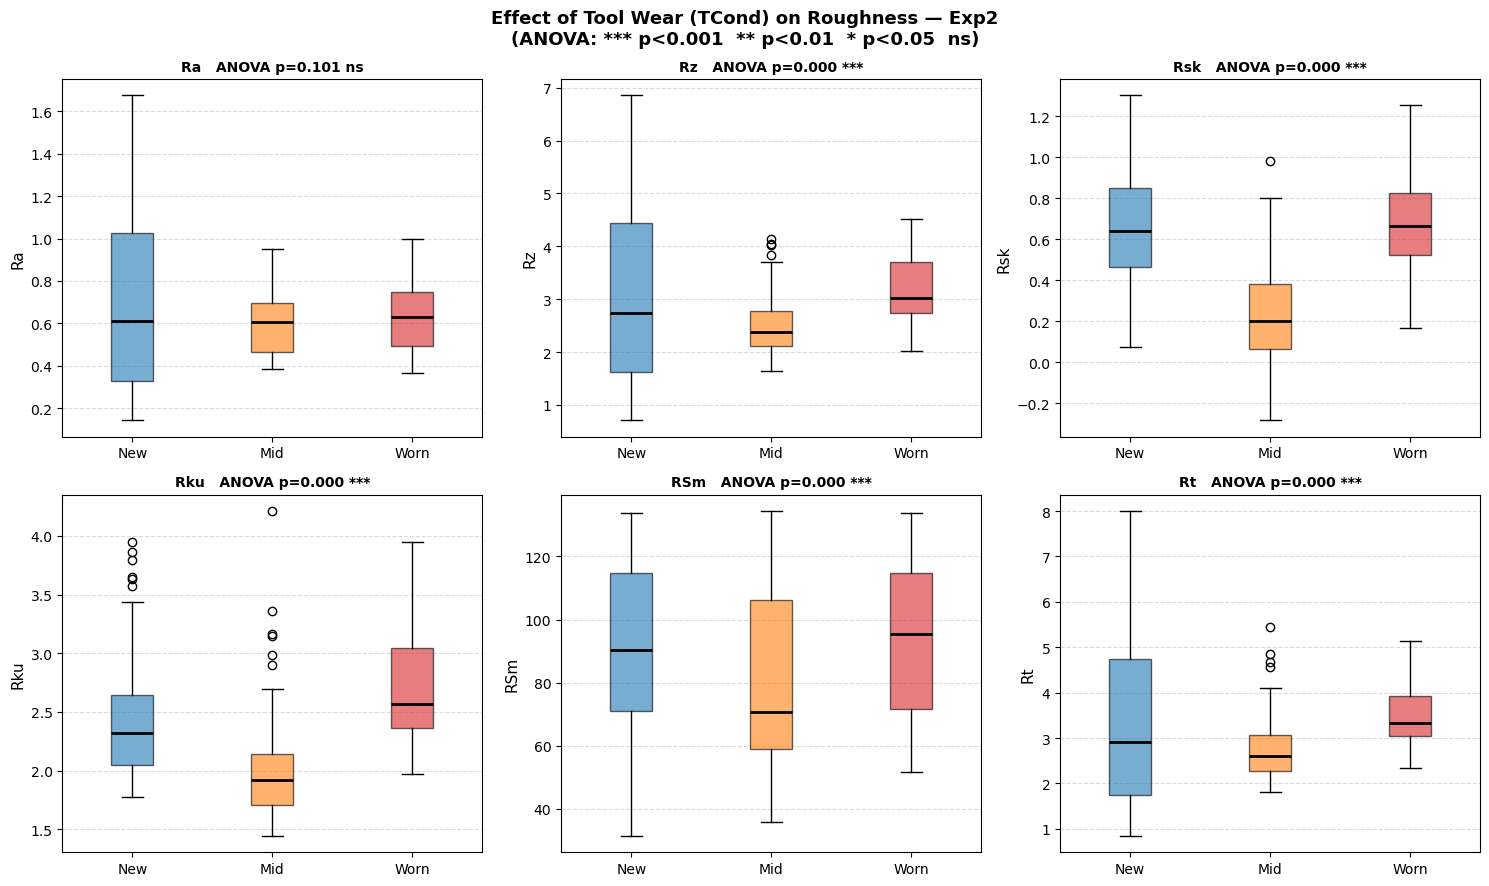

In [ ]:
# 3.3  TOOL WEAR (TCond) EFFECT — Boxplots + ANOVA

tcond_labels = {0.0: 'New (0.0)', 0.1: 'Mid (0.1)', 0.3: 'Worn (0.3)'}
df2['TCond_label'] = df2['TCond'].map(tcond_labels)
order = ['New (0.0)', 'Mid (0.1)', 'Worn (0.3)']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    'Effect of Tool Wear (TCond) on Roughness — Exp2\n'
    '(ANOVA: *** p<0.001  ** p<0.01  * p<0.05  ns)',
    fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, ROUGHNESS_COLS):
    bp = ax.boxplot(
        [df2[df2['TCond_label'] == lbl][col].dropna() for lbl in order],
        labels=['New', 'Mid', 'Worn'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], PALETTE_TCOND):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    groups = [df2[df2['TCond_label'] == lbl][col].dropna() for lbl in order]
    _, p_val = stats.f_oneway(*groups)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    ax.set_title(f'{col}   ANOVA p={p_val:.3f} {sig}', fontsize=10, fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig_03_tcond_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

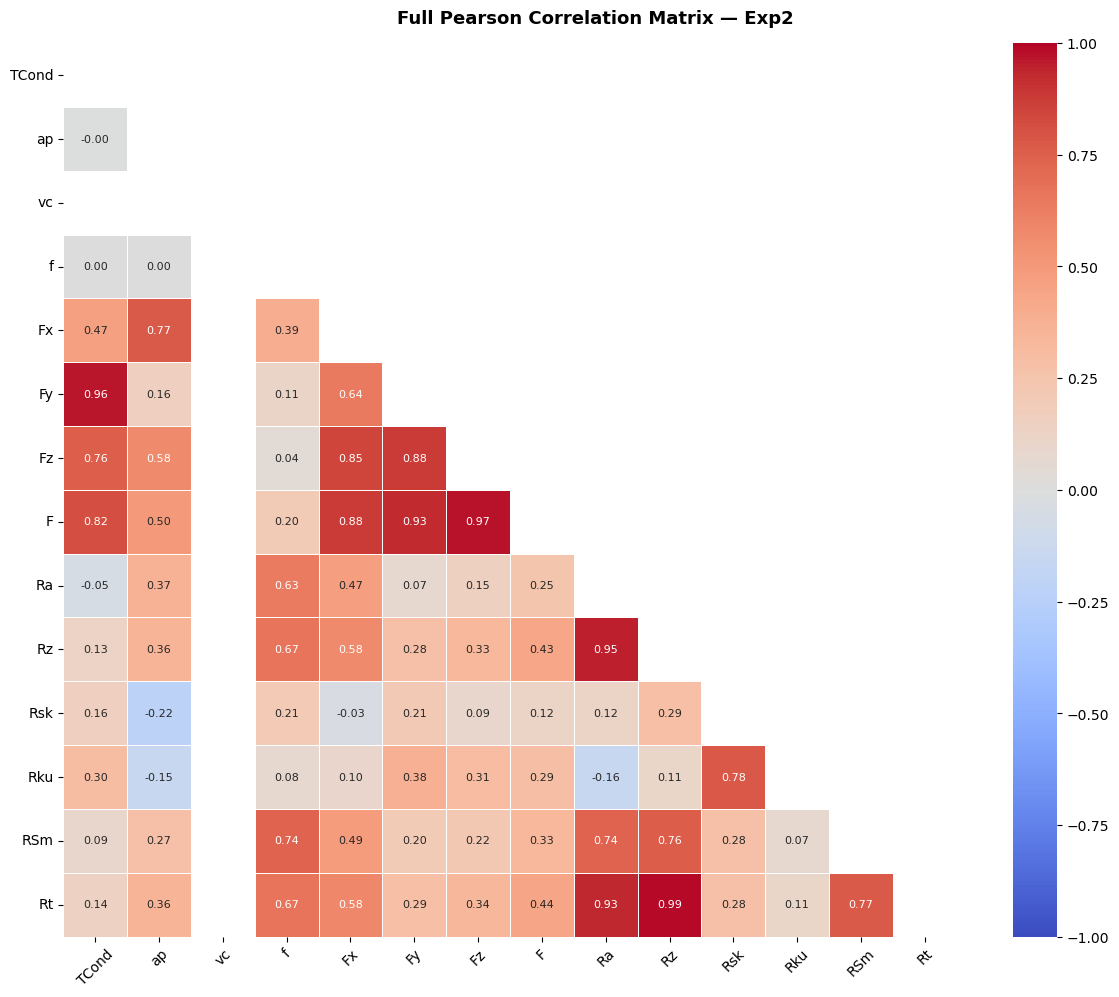

In [ ]:

# 3.5  FULL CORRELATION MATRIX — Exp2
numeric_cols = INPUT_COLS + FORCE_COLS + ROUGHNESS_COLS
corr_matrix  = df2[numeric_cols].corr()
mask         = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Full Pearson Correlation Matrix — Exp2',
             fontsize=13, fontweight='bold')

sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, square=True
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('fig_05_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Preprocessing & Feature Engineering

In [ ]:
# 4.1  FEATURE ENGINEERING

def engineer_features(df):
    """
    Physics-informed features:
      f_squared    : f^2  ->  Ra ~ f^2/(8r) in ideal turning
      Fy_Fz_ratio  : Fy/Fz  ->  passive/feed force ratio, sensitive to flank wear
      TCond_x_f    : TCond*f  ->  wear-feed interaction
    """
    d = df.copy()
    d['f_squared']   = d['f'] ** 2
    d['Fy_Fz_ratio'] = d['Fy'] / (d['Fz'] + 1e-9)
    d['TCond_x_f']   = d['TCond'] * d['f']
    return d

df2_feat = engineer_features(df2)

print('New features added: f_squared, Fy_Fz_ratio, TCond_x_f')
print(df2_feat[['f_squared', 'Fy_Fz_ratio', 'TCond_x_f']].describe().round(4))

New features added: f_squared, Fy_Fz_ratio, TCond_x_f
       f_squared  Fy_Fz_ratio  TCond_x_f
count   288.0000     288.0000   288.0000
mean      0.0105       1.6108     0.0133
std       0.0045       0.4843     0.0131
min       0.0049       0.8821     0.0000
25%       0.0073       1.1865     0.0000
50%       0.0101       1.5649     0.0100
75%       0.0133       2.0751     0.0225
max       0.0169       2.3093     0.0390


VIF Results:
  vc              VIF =  1415.53  <- HIGH
  f               VIF =   136.91  <- HIGH
  Fy              VIF =   127.49  <- HIGH
  f_squared       VIF =   126.93  <- HIGH
  TCond           VIF =   114.47  <- HIGH
  Fz              VIF =    45.66  <- HIGH
  ap              VIF =    39.17  <- HIGH
  Fy_Fz_ratio     VIF =    32.83  <- HIGH
  TCond_x_f       VIF =    32.69  <- HIGH


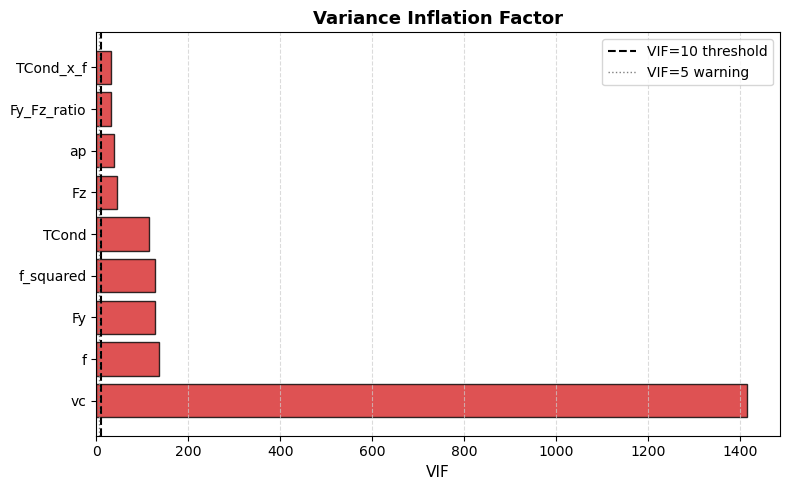

In [ ]:
# 4.2  VIF — multicollinearity check
# Fx and F dropped: Fx correlated with Fy; F = sqrt(Fx2+Fy2+Fz2)

CANDIDATE_FEATURES = ['TCond', 'ap', 'vc', 'f', 'Fy', 'Fz',
                      'f_squared', 'Fy_Fz_ratio', 'TCond_x_f']

X_vif    = df2_feat[CANDIDATE_FEATURES].dropna()
vif_data = pd.DataFrame({
    'Feature': CANDIDATE_FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('VIF Results:')
for _, row in vif_data.iterrows():
    flag = '  <- HIGH' if row['VIF'] > 10 else ''
    print(f"  {row['Feature']:<15} VIF = {row['VIF']:>8.2f}{flag}")

fig, ax = plt.subplots(figsize=(8, 5))
colors_vif = ['#d62728' if v > 10 else '#ff7f0e' if v > 5 else '#2ca02c'
              for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'],
        color=colors_vif, alpha=0.8, edgecolor='black')
ax.axvline(10, color='black', linestyle='--', lw=1.5, label='VIF=10 threshold')
ax.axvline(5,  color='gray',  linestyle=':',  lw=1.0, label='VIF=5 warning')
ax.set_title('Variance Inflation Factor', fontweight='bold')
ax.set_xlabel('VIF')
ax.legend()
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('fig_06_vif.png', dpi=150, bbox_inches='tight')
plt.show()

Final feature set (9 features):
  - TCond
  - ap
  - f
  - vc
  - Fy
  - Fz
  - f_squared
  - Fy_Fz_ratio
  - TCond_x_f


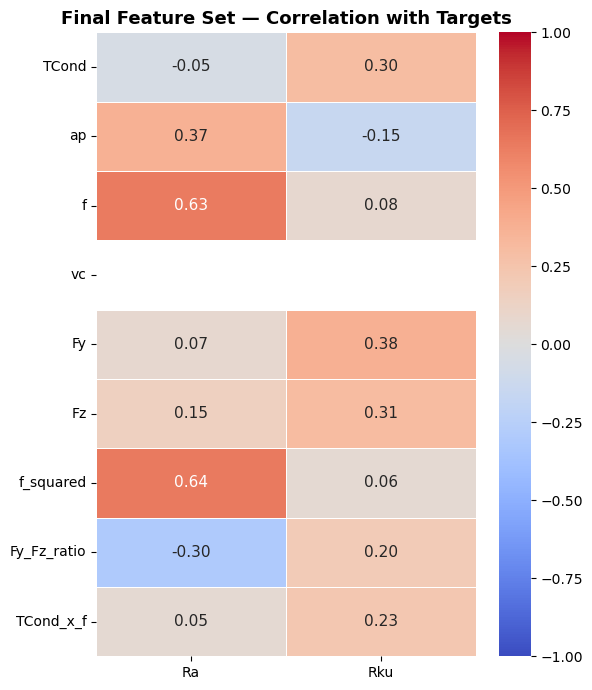

In [ ]:
# 4.3  FINAL FEATURE SET + CORRELATION WITH TARGETS

FINAL_FEATURES = [
    'TCond', 'ap', 'f', 'vc', 'Fy', 'Fz',
    'f_squared', 'Fy_Fz_ratio', 'TCond_x_f'
]
TARGETS = ['Ra', 'Rku']

print(f'Final feature set ({len(FINAL_FEATURES)} features):')
for f in FINAL_FEATURES:
    print(f'  - {f}')

fig, ax = plt.subplots(figsize=(6, 7))
sub = df2_feat[FINAL_FEATURES + TARGETS].corr().loc[FINAL_FEATURES, TARGETS]
sns.heatmap(sub, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})
ax.set_title('Final Feature Set — Correlation with Targets', fontweight='bold')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('fig_07_final_feature_corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 4.4  TRAIN / VAL / TEST SPLIT + SCALING
# Fix vs original: scaler fitted ONLY on train (no data leakage)

X_all = df2_feat[FINAL_FEATURES].copy()
y_Ra  = df2_feat['Ra'].copy()
y_Rku = df2_feat['Rku'].copy()

# Stratified 80/20 split on feed rate f
sep = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
for train_idx, test_idx in sep.split(X_all, df2_feat['f']):
    X_trainval  = X_all.iloc[train_idx].reset_index(drop=True)
    X_test      = X_all.iloc[test_idx].reset_index(drop=True)
    y_Ra_tv     = y_Ra.iloc[train_idx].reset_index(drop=True)
    y_Ra_test   = y_Ra.iloc[test_idx].reset_index(drop=True)
    y_Rku_tv    = y_Rku.iloc[train_idx].reset_index(drop=True)
    y_Rku_test  = y_Rku.iloc[test_idx].reset_index(drop=True)

X_train, X_val, y_Ra_train, y_Ra_val, y_Rku_train, y_Rku_val = train_test_split(
    X_trainval, y_Ra_tv, y_Rku_tv, test_size=0.20, random_state=42
)

scaler     = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
X_tv_sc    = scaler.transform(X_trainval)
y_Ra_tv_arr  = y_Ra_tv.values
y_Rku_tv_arr = y_Rku_tv.values

print('Split summary:')
print(f'  Train      : {X_train_sc.shape[0]} samples ({X_train_sc.shape[0]/len(X_all)*100:.1f}%)')
print(f'  Validation : {X_val_sc.shape[0]} samples ({X_val_sc.shape[0]/len(X_all)*100:.1f}%)')
print(f'  Test       : {X_test_sc.shape[0]} samples ({X_test_sc.shape[0]/len(X_all)*100:.1f}%)')

Split summary:
  Train      : 184 samples (63.9%)
  Validation : 46 samples (16.0%)
  Test       : 58 samples (20.1%)


---
## 5. XGBoost — Hyperparameter Search & Training

> **Model selection:** XGBoost was selected after comparing ANN, BiLSTM and XGBoost.  
> With 288 samples, gradient boosting significantly outperforms neural networks:  
> XGBoost builds local decision rules handling non-linear interactions natively  
> with no assumption on input distribution and no requirement for large data volume.

In [ ]:
# 5.1  RANDOMIZED HYPERPARAMETER SEARCH

param_grid = {
    'n_estimators':     [100, 200, 300, 500, 700],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.05, 0.1, 0.2, 0.3],
    'reg_alpha':        [0, 0.01, 0.05, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 1.5, 2.0, 3.0],
}

base_xgb = XGBRegressor(objective='reg:squarederror',
                         random_state=42, n_jobs=-1, verbosity=0)

print('Searching best hyperparameters for Ra ...')
search_Ra = RandomizedSearchCV(base_xgb, param_grid, n_iter=50,
                                scoring='neg_mean_absolute_error',
                                cv=5, random_state=42, n_jobs=-1, verbose=0)
search_Ra.fit(X_tv_sc, y_Ra_tv_arr)
print(f'  Best CV MAE (Ra)  : {-search_Ra.best_score_:.4f}')

print('Searching best hyperparameters for Rku ...')
search_Rku = RandomizedSearchCV(base_xgb, param_grid, n_iter=50,
                                 scoring='neg_mean_absolute_error',
                                 cv=5, random_state=42, n_jobs=-1, verbose=0)
search_Rku.fit(X_tv_sc, y_Rku_tv_arr)
print(f'  Best CV MAE (Rku) : {-search_Rku.best_score_:.4f}')

Searching best hyperparameters for Ra ...
  Best CV MAE (Ra)  : 0.0291
Searching best hyperparameters for Rku ...
  Best CV MAE (Rku) : 0.1361


In [ ]:
# 5.2  FINAL REFIT WITH EARLY STOPPING

def build_final(best_params):
    p = best_params.copy()
    p['n_estimators'] = 1000
    return XGBRegressor(**p, objective='reg:squarederror',
                         random_state=42, n_jobs=-1, verbosity=0,
                         early_stopping_rounds=50, eval_metric='mae')

xgb_Ra = build_final(search_Ra.best_params_)
xgb_Ra.fit(X_train_sc, y_Ra_train,
            eval_set=[(X_train_sc, y_Ra_train), (X_val_sc, y_Ra_val)],
            verbose=False)

xgb_Rku = build_final(search_Rku.best_params_)
xgb_Rku.fit(X_train_sc, y_Rku_train,
             eval_set=[(X_train_sc, y_Rku_train), (X_val_sc, y_Rku_val)],
             verbose=False)

print(f'Best iteration — Ra  : {xgb_Ra.best_iteration}')
print(f'Best iteration — Rku : {xgb_Rku.best_iteration}')

Best iteration — Ra  : 74
Best iteration — Rku : 112


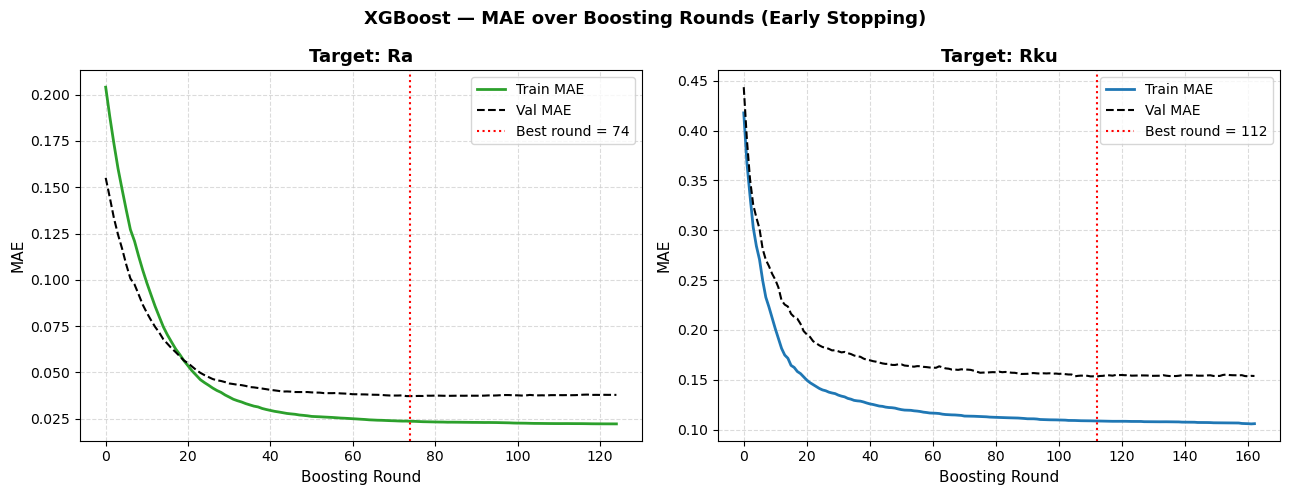

In [ ]:
# 5.3  LEARNING CURVES (boosting rounds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('XGBoost — MAE over Boosting Rounds (Early Stopping)',
             fontsize=13, fontweight='bold')

for ax, (model, target, color) in zip(axes, [
        (xgb_Ra,  'Ra',  C_RA),
        (xgb_Rku, 'Rku', C_RKU)]):
    results   = model.evals_result()
    train_mae = results['validation_0']['mae']
    val_mae   = results['validation_1']['mae']
    rounds    = range(len(train_mae))
    ax.plot(rounds, train_mae, color=color,   lw=2,   label='Train MAE')
    ax.plot(rounds, val_mae,   color='black', lw=1.5,
            linestyle='--', label='Val MAE')
    ax.axvline(model.best_iteration, color='red', lw=1.5,
               linestyle=':', label=f'Best round = {model.best_iteration}')
    ax.set_title(f'Target: {target}', fontweight='bold')
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('MAE')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('fig_08_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Model Evaluation

In [ ]:
# 6.1  TEST SET METRICS

pred_Ra  = xgb_Ra.predict(X_test_sc)
pred_Rku = xgb_Rku.predict(X_test_sc)

def compute_metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

m_Ra  = compute_metrics(y_Ra_test.values,  pred_Ra)
m_Rku = compute_metrics(y_Rku_test.values, pred_Rku)

df_metrics = pd.DataFrame([
    {'Target': 'Ra',  **{k: round(v, 4) for k, v in m_Ra.items()}},
    {'Target': 'Rku', **{k: round(v, 4) for k, v in m_Rku.items()}},
])

print('XGBoost — Test Set Results')
print('=' * 50)
print(df_metrics.to_string(index=False))
print('=' * 50)

# 5-fold CV stability check
cv_Ra  = cross_val_score(search_Ra.best_estimator_,  X_tv_sc, y_Ra_tv_arr,
                          cv=5, scoring='r2', n_jobs=-1)
cv_Rku = cross_val_score(search_Rku.best_estimator_, X_tv_sc, y_Rku_tv_arr,
                          cv=5, scoring='r2', n_jobs=-1)
print(f'\n5-Fold CV R²  Ra  : {cv_Ra.mean():.4f} ± {cv_Ra.std():.4f}')
print(f'5-Fold CV R²  Rku : {cv_Rku.mean():.4f} ± {cv_Rku.std():.4f}')

XGBoost — Test Set Results
Target     R2    MAE   RMSE   MAPE
    Ra 0.9655 0.0323 0.0448 6.1436
   Rku 0.8813 0.1285 0.1801 5.4633

5-Fold CV R²  Ra  : 0.9752 ± 0.0035
5-Fold CV R²  Rku : 0.8633 ± 0.0294


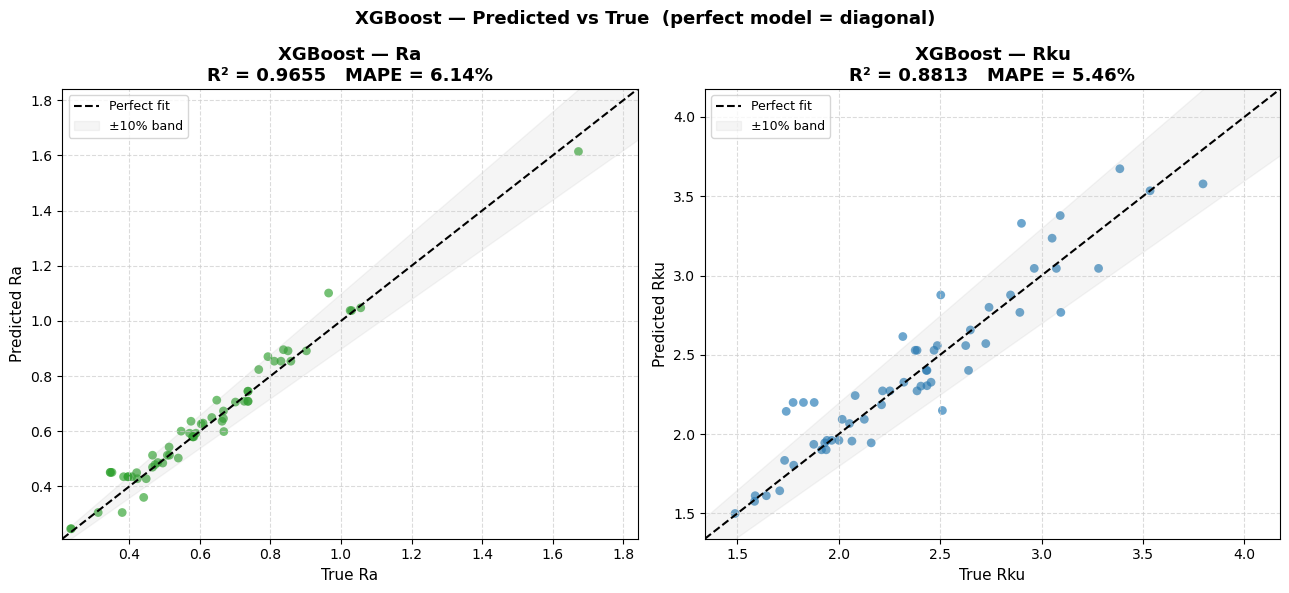

In [ ]:
# 6.3  PARITY PLOTS — predicted vs true

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('XGBoost — Predicted vs True  (perfect model = diagonal)',
             fontsize=13, fontweight='bold')

for ax, (y_true, y_pred, target, color) in zip(axes, [
        (y_Ra_test.values,  pred_Ra,  'Ra',  C_RA),
        (y_Rku_test.values, pred_Rku, 'Rku', C_RKU)]):
    ax.scatter(y_true, y_pred, alpha=0.65, s=40, color=color, edgecolors='none')
    lim = [min(y_true.min(), y_pred.min()) * 0.9,
           max(y_true.max(), y_pred.max()) * 1.1]
    ax.plot(lim, lim, color='black', linestyle='--', lw=1.5, label='Perfect fit')
    x_cb = np.linspace(lim[0], lim[1], 200)
    ax.fill_between(x_cb, x_cb*0.9, x_cb*1.1,
                    alpha=0.08, color='gray', label='±10% band')
    r2_v   = r2_score(y_true, y_pred)
    mape_v = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    ax.set_title(f'XGBoost — {target}\nR² = {r2_v:.4f}   MAPE = {mape_v:.2f}%',
                 fontweight='bold')
    ax.set_xlabel(f'True {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('fig_10_parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()

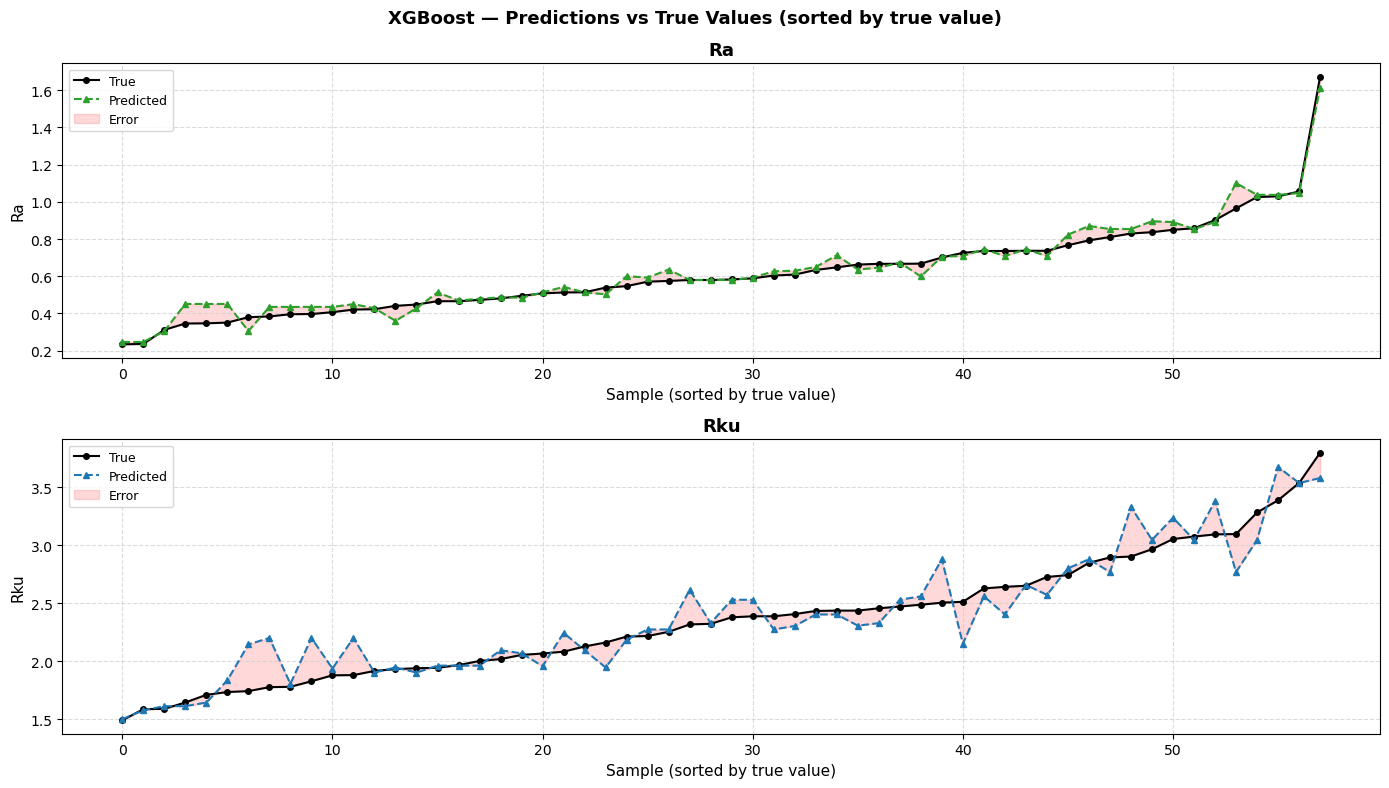

In [ ]:
# 6.4  PREDICTION TIMELINE — sorted by true value

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('XGBoost — Predictions vs True Values (sorted by true value)',
             fontsize=13, fontweight='bold')

for ax, (y_true, y_pred, target, color) in zip(axes, [
        (y_Ra_test.values,  pred_Ra,  'Ra',  C_RA),
        (y_Rku_test.values, pred_Rku, 'Rku', C_RKU)]):
    order = np.argsort(y_true)
    x     = np.arange(len(y_true))
    ax.plot(x, y_true[order], color='black', lw=1.5,
            marker='o', markersize=4, label='True')
    ax.plot(x, y_pred[order], color=color,   lw=1.5,
            marker='^', markersize=4, linestyle='--', label='Predicted')
    ax.fill_between(x, y_true[order], y_pred[order],
                    alpha=0.15, color='red', label='Error')
    ax.set_title(target, fontweight='bold')
    ax.set_xlabel('Sample (sorted by true value)')
    ax.set_ylabel(target)
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.savefig('fig_11_prediction_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Summary

In [ ]:
# 7.1  SAVE MODELS

import os, json
os.makedirs('./models', exist_ok=True)

joblib.dump(xgb_Ra,  './models/xgb_Ra.joblib')
joblib.dump(xgb_Rku, './models/xgb_Rku.joblib')
joblib.dump(scaler,  './models/scaler.joblib')

with open('./models/best_params.json', 'w') as f:
    json.dump({'Ra': search_Ra.best_params_,
               'Rku': search_Rku.best_params_}, f, indent=2)

print('Models saved to ./models/')

Models saved to ./models/
